# Movie Genre Classification from Posters

Can a CNN tell a movie's genre from its poster alone? This notebook classifies posters as **Action, Comedy, Horror or Romance** with transfer learning in PyTorch. It compares four ImageNet-pretrained backbones under one identical training setup, then fine-tunes the best one.

| | |
|---|---|
| **Dataset** | [Four-Genre Movie Poster Images](https://www.kaggle.com/datasets/zulkarnainsaurav/four-genre-movie-poster-images) (Kaggle, Apache 2.0): 1,325 IMDB posters |
| **Split** | Stratified 70 / 15 / 15 train / val / test, seed 42 |
| **Backbones** | ResNet18 · ResNet50 · DenseNet121 · VGG16 |
| **Stage 1** | Frozen backbone with a new linear head (linear probe). Every model is trained the same way. |
| **Stage 2** | Fine-tune the last block of the best backbone with a lower learning rate |
| **Selection** | Each model keeps its best-validation-accuracy checkpoint. The test set is used only once, at the end. |

## 1. Setup

In [1]:
import gc
import os
import random
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

SEED = 42
EPOCHS = 8
BATCH_SIZE = 32
RAW_DIR = Path("data/four_genre_posters")     # one sub-folder per genre
SPLIT_DIR = Path("data/four_genre_posters_split")
ASSETS = Path("assets")
CHECKPOINTS = Path("checkpoints")
ASSETS.mkdir(exist_ok=True)
CHECKPOINTS.mkdir(exist_ok=True)

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0 if os.name == "nt" else 2   # worker processes are unreliable in Windows notebooks
sns.set_theme(style="whitegrid")
print("Device:", device)

Device: cuda


## 2. Data

If the posters are not already in `data/four_genre_posters/`, they are downloaded from Kaggle with `kagglehub`. Then a reproducible, **stratified** 70/15/15 split is written to `data/four_genre_posters_split/{train,val,test}/<genre>/`.

In [2]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".webp"}

def find_genre_root(base):
    # Return the first directory whose sub-folders are the genre folders.
    for d in [base, *sorted(p for p in Path(base).rglob("*") if p.is_dir())]:
        subs = [s for s in d.iterdir() if s.is_dir()]
        if len(subs) >= 2 and all(any(f.suffix.lower() in IMG_EXT for f in s.iterdir()) for s in subs):
            return d
    raise FileNotFoundError(f"No genre folders found under {base}")

if not RAW_DIR.exists():
    import kagglehub
    downloaded = Path(kagglehub.dataset_download("zulkarnainsaurav/four-genre-movie-poster-images"))
    # The archive also ships a "four_genre_posters_updated" variant; this project uses the original 1,325-image set.
    shutil.copytree(find_genre_root(downloaded / "four_genre_posters"), RAW_DIR)

raw_root = find_genre_root(RAW_DIR)
files = sorted(f for f in raw_root.rglob("*") if f.suffix.lower() in IMG_EXT)
labels = [f.parent.name for f in files]
print(pd.Series(labels).value_counts().rename("images").to_frame().T.to_string(), "\nTotal:", len(files))

        Horror  Action  Comedy  Romance
images     398     337     321      269 
Total: 1325


In [3]:
if not SPLIT_DIR.exists():
    train_f, rest_f, train_y, rest_y = train_test_split(files, labels, test_size=0.30, stratify=labels, random_state=SEED)
    val_f, test_f, val_y, test_y = train_test_split(rest_f, rest_y, test_size=0.50, stratify=rest_y, random_state=SEED)
    for split, fs, ys in [("train", train_f, train_y), ("val", val_f, val_y), ("test", test_f, test_y)]:
        for f, y in zip(fs, ys):
            dst = SPLIT_DIR / split / y / f.name
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(f, dst)

split_counts = pd.DataFrame({
    split: {g.name: len(list(g.iterdir())) for g in sorted((SPLIT_DIR / split).iterdir())}
    for split in ["train", "val", "test"]
})
split_counts.loc["Total"] = split_counts.sum()
split_counts

,train,val,test
Action,236,50,51
Comedy,225,48,48
Horror,278,60,60
Romance,188,41,40
Total,927,199,199


### A look at the data

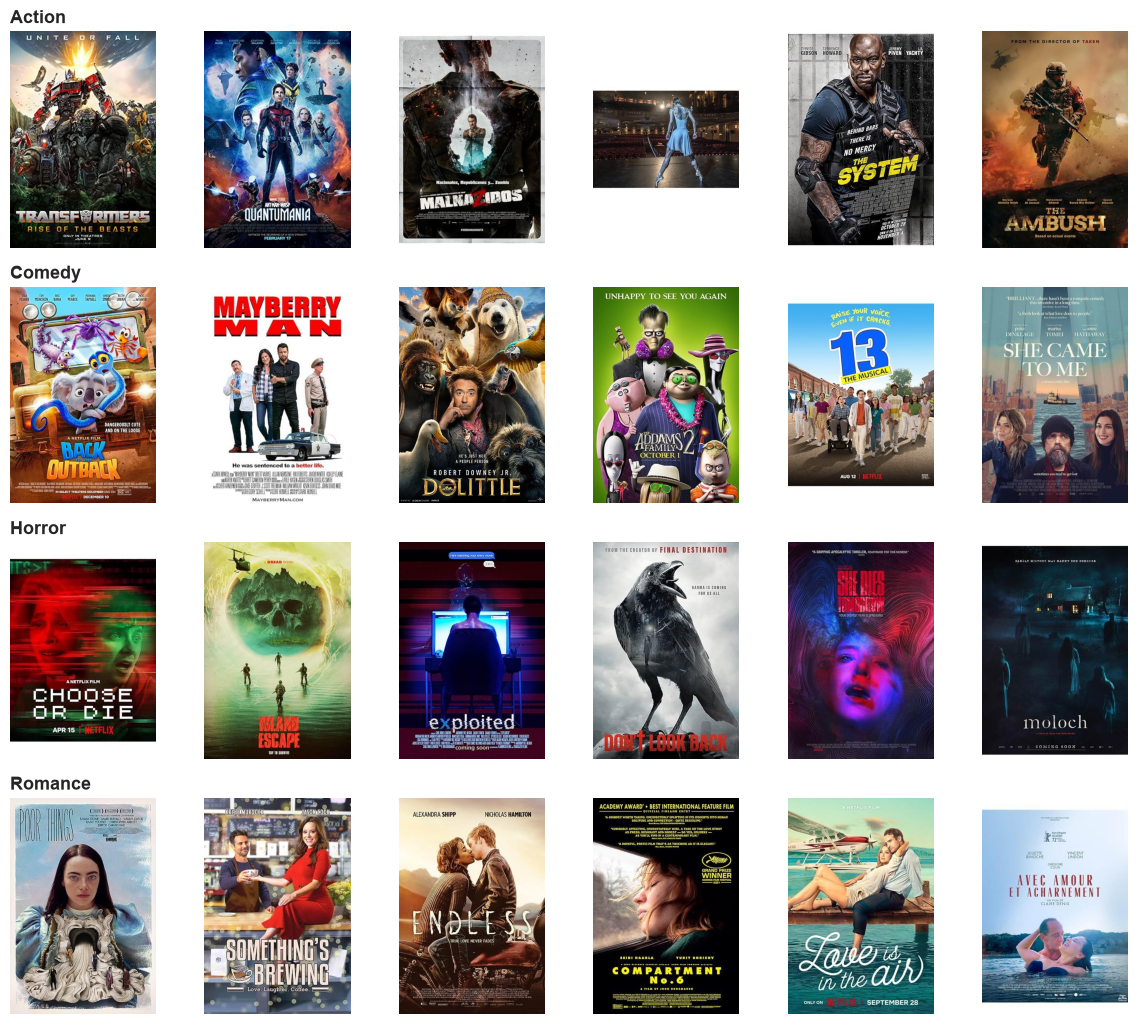

In [4]:
genres = sorted(p.name for p in (SPLIT_DIR / "train").iterdir())
rng = random.Random(SEED)
fig, axes = plt.subplots(len(genres), 6, figsize=(12, 2.6 * len(genres)))
for r, genre in enumerate(genres):
    samples = rng.sample(sorted((SPLIT_DIR / "train" / genre).iterdir()), 6)
    for c, path in enumerate(samples):
        axes[r, c].imshow(Image.open(path).convert("RGB"))
        axes[r, c].axis("off")
    axes[r, 0].set_title(genre, loc="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Transforms & loaders
All images are resized to 224×224 and normalized with ImageNet statistics. Training images are also augmented with a random horizontal flip, ±10° rotation and colour jitter.

In [5]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(SPLIT_DIR / "train", train_tf)
val_ds = datasets.ImageFolder(SPLIT_DIR / "val", eval_tf)
test_ds = datasets.ImageFolder(SPLIT_DIR / "test", eval_tf)
class_names = train_ds.classes

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
print("Classes:", class_names, "| train/val/test:", len(train_ds), len(val_ds), len(test_ds))

Classes: ['Action', 'Comedy', 'Horror', 'Romance'] | train/val/test: 927 199 199


## 3. Models

`build_model()` loads a pretrained backbone, freezes **all** of its weights and swaps the final layer for a new 4-class linear head. Only the head is trained, so the four backbones are compared fairly as frozen feature extractors.

In [6]:
BACKBONES = {
    "ResNet18": (models.resnet18, models.ResNet18_Weights.IMAGENET1K_V1),
    "ResNet50": (models.resnet50, models.ResNet50_Weights.IMAGENET1K_V2),
    "DenseNet121": (models.densenet121, models.DenseNet121_Weights.IMAGENET1K_V1),
    "VGG16": (models.vgg16, models.VGG16_Weights.IMAGENET1K_V1),
}

def build_model(name, num_classes=len(class_names), pretrained=True):
    ctor, weights = BACKBONES[name]
    model = ctor(weights=weights if pretrained else None)
    for p in model.parameters():
        p.requires_grad = False
    if name.startswith("ResNet"):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "DenseNet121":
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif name == "VGG16":
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model.to(device)

def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, sum(p.numel() for p in model.parameters())

## 4. Training & evaluation helpers

`train_model()` runs the epochs and records train/val loss and accuracy. Whenever validation accuracy improves it writes a checkpoint to `checkpoints/`, and at the end it **restores the best-validation weights**. A checkpoint holds only what training changed: the trainable weights plus BatchNorm running statistics. The frozen backbone weights come from torchvision, so the files stay a few MB instead of up to 530 MB for VGG16. The test set is never used for model selection.

In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += y.size(0)
    return total_loss / n, 100 * correct / n


def trained_state(model):
    keep = {n for n, p in model.named_parameters() if p.requires_grad} | {n for n, _ in model.named_buffers()}
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items() if k in keep}


def load_trained_state(model, path):
    result = model.load_state_dict(torch.load(path, map_location=device), strict=False)
    assert not result.unexpected_keys, f"checkpoint does not match model: {result.unexpected_keys[:3]}"


def train_model(model, name, epochs=EPOCHS, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam((p for p in model.parameters() if p.requires_grad), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    ckpt = CHECKPOINTS / f"{name.lower()}.pth"
    best_acc, best_epoch = -1.0, 0
    start = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)
        for k, v in zip(history, (tr_loss, va_loss, tr_acc, va_acc)):
            history[k].append(v)
        if va_acc > best_acc:  # checkpoint to disk rather than an in-memory copy (VGG16 alone is ~530 MB)
            best_acc, best_epoch = va_acc, epoch
            torch.save(trained_state(model), ckpt)
        print(f"[{name}] epoch {epoch}/{epochs}  train {tr_acc:5.1f}% / {tr_loss:.3f}   val {va_acc:5.1f}% / {va_loss:.3f}")
    load_trained_state(model, ckpt)
    print(f"[{name}] best val acc {best_acc:.1f}% at epoch {best_epoch}  ({time.time() - start:.0f}s)\n")
    return history, best_acc, best_epoch


@torch.no_grad()
def predict(model, loader):
    model.eval()
    y_true, y_pred, probs = [], [], []
    for x, y in loader:
        out = model(x.to(device))
        probs.append(out.softmax(1).cpu())
        y_pred.extend(out.argmax(1).cpu().tolist())
        y_true.extend(y.tolist())
    return np.array(y_true), np.array(y_pred), torch.cat(probs).numpy()

## 5. Stage 1: compare frozen backbones

All four backbones get the same setup: Adam (lr 1e-3), cross-entropy loss, 8 epochs, batch size 32. Test-set predictions are stored right after each model finishes so the model can be freed from memory. They are only compared in the next section, and they play no part in selecting a model.

In [8]:
histories, summary, test_preds = {}, [], {}
for name in BACKBONES:
    seed_everything()
    model = build_model(name)
    trainable, total = count_params(model)
    history, best_val, best_epoch = train_model(model, name)
    histories[name] = history
    test_preds[name] = predict(model, test_loader)
    summary.append({"Backbone": name, "Trainable params": trainable, "Total params": total,
                    "Best val acc (%)": best_val, "Best epoch": best_epoch,
                    "Val loss @ best": history["val_loss"][best_epoch - 1]})
    del model
    gc.collect()

[ResNet18] epoch 1/8  train  35.2% / 1.352   val  51.8% / 1.158


[ResNet18] epoch 2/8  train  57.0% / 1.075   val  63.3% / 0.999


[ResNet18] epoch 3/8  train  62.4% / 0.950   val  63.8% / 0.950


[ResNet18] epoch 4/8  train  65.3% / 0.886   val  64.8% / 0.909


[ResNet18] epoch 5/8  train  68.2% / 0.861   val  66.8% / 0.913


...

[VGG16] epoch 4/8  train  68.9% / 0.746   val  61.3% / 0.928


[VGG16] epoch 5/8  train  71.5% / 0.718   val  64.3% / 0.924


[VGG16] epoch 6/8  train  72.8% / 0.694   val  61.8% / 0.897


[VGG16] epoch 7/8  train  73.5% / 0.661   val  64.3% / 0.927


[VGG16] epoch 8/8  train  72.3% / 0.688   val  62.8% / 0.917
[VGG16] best val acc 64.3% at epoch 5  (233s)



### Learning curves

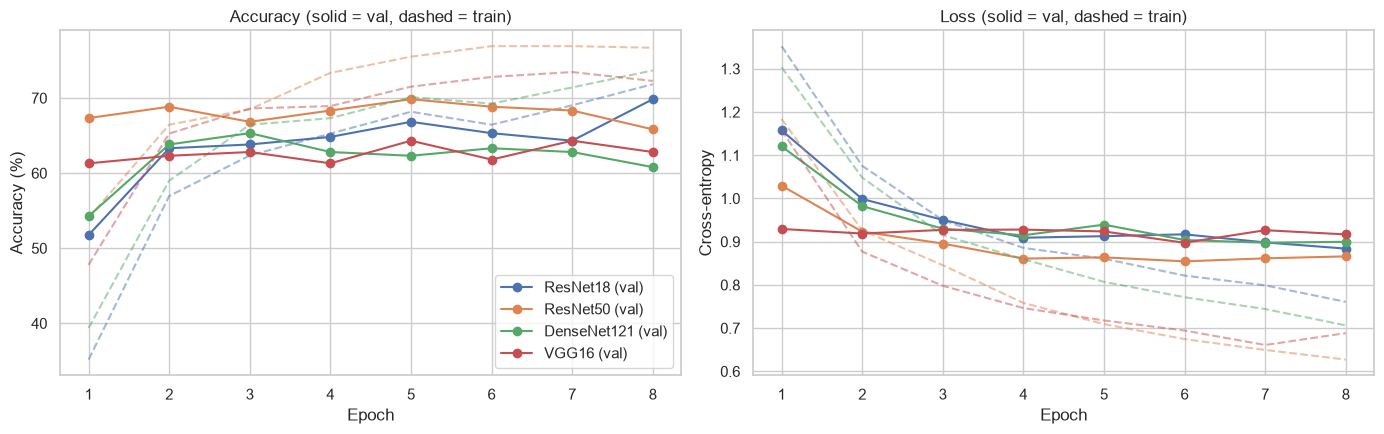

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, h in histories.items():
    ep = range(1, len(h["val_acc"]) + 1)
    line, = axes[0].plot(ep, h["val_acc"], marker="o", label=f"{name} (val)")
    axes[0].plot(ep, h["train_acc"], ls="--", color=line.get_color(), alpha=0.5)
    axes[1].plot(ep, h["val_loss"], marker="o", color=line.get_color(), label=f"{name} (val)")
    axes[1].plot(ep, h["train_loss"], ls="--", color=line.get_color(), alpha=0.5)
axes[0].set(title="Accuracy (solid = val, dashed = train)", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].set(title="Loss (solid = val, dashed = train)", xlabel="Epoch", ylabel="Cross-entropy")
axes[0].legend()
plt.tight_layout()
plt.savefig(ASSETS / "learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()

### Test-set comparison
Every backbone is scored on the held-out test set using its own best-validation checkpoint.

In [10]:
for row in summary:
    y_true, y_pred, probs = test_preds[row["Backbone"]]
    row["Test acc (%)"] = 100 * (y_true == y_pred).mean()
    row["Test macro-F1"] = f1_score(y_true, y_pred, average="macro")

results = (pd.DataFrame(summary)
           .sort_values("Test acc (%)", ascending=False)
           .reset_index(drop=True))
results.style.format({"Trainable params": "{:,}", "Total params": "{:,}",
                      "Best val acc (%)": "{:.1f}", "Val loss @ best": "{:.3f}", "Test acc (%)": "{:.1f}", "Test macro-F1": "{:.3f}"}) \
       .highlight_max(subset=["Test acc (%)", "Test macro-F1"], color="#c7e9c0")

,Backbone,Trainable params,Total params,Best val acc (%),Best epoch,Val loss @ best,Test acc (%),Test macro-F1
0,ResNet50,"8,196","23,516,228",69.8,5,0.864,67.3,0.666
1,VGG16,"16,388","134,276,932",64.3,5,0.924,66.3,0.649
2,DenseNet121,"4,100","6,957,956",65.3,3,0.930,65.3,0.642
3,ResNet18,"2,052","11,178,564",69.8,8,0.884,59.8,0.581


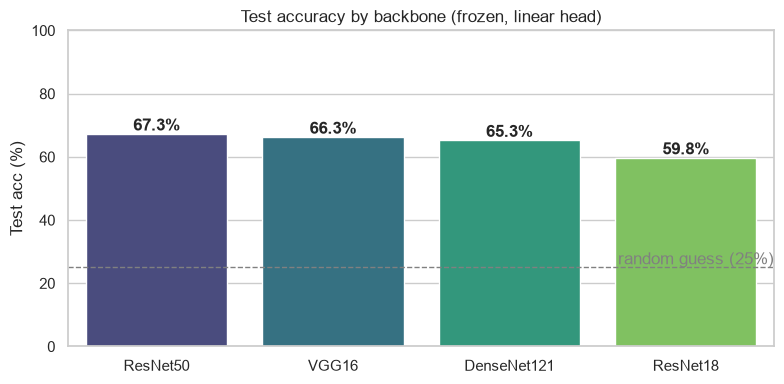

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
order = results["Backbone"]
sns.barplot(data=results, x="Backbone", y="Test acc (%)", hue="Backbone", order=order,
            palette="viridis", legend=False, ax=ax)
ax.axhline(100 / len(class_names), color="grey", ls="--", lw=1)
ax.text(len(order) - 0.5, 100 / len(class_names) + 1, "random guess (25%)", ha="right", color="grey")
for i, v in enumerate(results["Test acc (%)"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set(ylim=(0, 100), title="Test accuracy by backbone (frozen, linear head)", xlabel="")
plt.tight_layout()
plt.savefig(ASSETS / "backbone_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Stage 2: fine-tune the best backbone

The stage-1 winner is chosen by **validation** accuracy, which keeps test-set information out of the decision. With only 199 validation images, accuracy moves in steps of 0.5%, so two backbones can tie. Ties are broken by the lower validation loss. Its last block is then unfrozen and trained together with the head. The head starts from its stage-1 weights and uses a 10× lower learning rate, so the pretrained features change only slightly.

In [12]:
best_name = max(summary, key=lambda r: (r["Best val acc (%)"], -r["Val loss @ best"]))["Backbone"]
print("Selected on validation (accuracy, then loss):", best_name)
LAST_BLOCK = {"ResNet18": "layer4", "ResNet50": "layer4", "DenseNet121": "features.denseblock4", "VGG16": "features.28"}

def load_trained(name):
    model = build_model(name)
    load_trained_state(model, CHECKPOINTS / f"{name.lower()}.pth")
    return model

ft_model = load_trained(best_name)
for pname, p in ft_model.named_parameters():
    if pname.startswith(LAST_BLOCK[best_name]):
        p.requires_grad = True
print(f"Fine-tuning {best_name}: {count_params(ft_model)[0]:,} trainable params")

seed_everything()
ft_history, ft_best_val, ft_best_epoch = train_model(ft_model, f"{best_name}-finetuned", epochs=6, lr=1e-4)

Selected on validation (accuracy, then loss): ResNet50


Fine-tuning ResNet50: 14,972,932 trainable params


[ResNet50-finetuned] epoch 1/6  train  76.2% / 0.660   val  69.3% / 0.831


[ResNet50-finetuned] epoch 2/6  train  84.1% / 0.442   val  70.9% / 0.849


[ResNet50-finetuned] epoch 3/6  train  88.6% / 0.304   val  67.8% / 0.901


[ResNet50-finetuned] epoch 4/6  train  91.5% / 0.262   val  70.4% / 0.916


[ResNet50-finetuned] epoch 5/6  train  94.2% / 0.192   val  67.3% / 1.018


[ResNet50-finetuned] epoch 6/6  train  94.0% / 0.177   val  66.3% / 1.037


[ResNet50-finetuned] best val acc 70.9% at epoch 2  (172s)



In [13]:
y_true, y_pred, probs = predict(ft_model, test_loader)
base_true, base_pred, _ = test_preds[best_name]
comparison = pd.DataFrame({
    "Model": [f"{best_name} (frozen)", f"{best_name} (fine-tuned)"],
    "Best val acc (%)": [next(r["Best val acc (%)"] for r in summary if r["Backbone"] == best_name), ft_best_val],
    "Test acc (%)": [100 * (base_true == base_pred).mean(), 100 * (y_true == y_pred).mean()],
    "Test macro-F1": [f1_score(base_true, base_pred, average="macro"), f1_score(y_true, y_pred, average="macro")],
})
comparison.round(3)

,Model,Best val acc (%),Test acc (%),Test macro-F1
0,ResNet50 (frozen),69.849,67.337,0.666
1,ResNet50 (fine-tuned),70.854,63.819,0.629


The final model is whichever of the two variants has the higher **validation** accuracy. The test numbers above are reported for both, but they play no part in choosing.

In [14]:
if ft_best_val > comparison.loc[0, "Best val acc (%)"]:
    final_name, final_model = f"{best_name} (fine-tuned)", ft_model
else:
    del ft_model
    final_name, final_model = f"{best_name} (frozen)", load_trained(best_name)
    y_true, y_pred = base_true, base_pred
    probs = test_preds[best_name][2]
print("Final model:", final_name, f"| test accuracy {100 * (y_true == y_pred).mean():.1f}%")

Final model: ResNet50 (fine-tuned) | test accuracy 63.8%


## 7. Final model: per-class results

              precision    recall  f1-score   support

      Action      0.688     0.647     0.667        51
      Comedy      0.639     0.479     0.548        48
      Horror      0.698     0.733     0.715        60
     Romance      0.519     0.675     0.587        40

    accuracy                          0.638       199
   macro avg      0.636     0.634     0.629       199
weighted avg      0.645     0.638     0.637       199



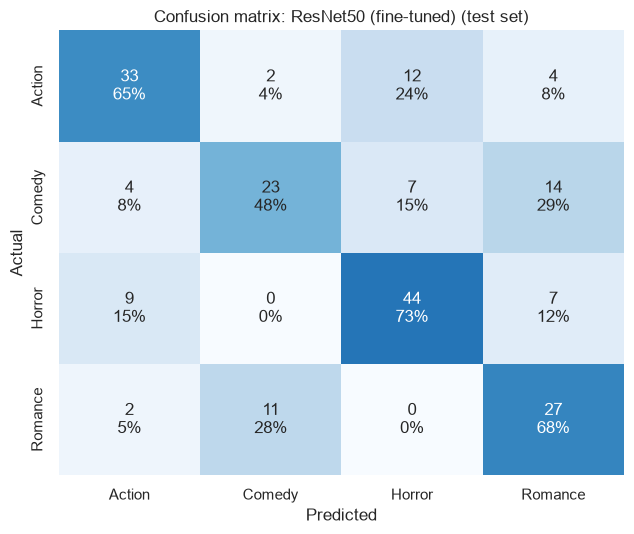

In [15]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True)
annot = np.array([[f"{c}\n{p:.0%}" for c, p in zip(row_c, row_p)] for row_c, row_p in zip(cm, cm_pct)])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_pct, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set(title=f"Confusion matrix: {final_name} (test set)", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.savefig(ASSETS / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

### Sample predictions
These are random test posters. A green title means the prediction was correct, and red means it was wrong.

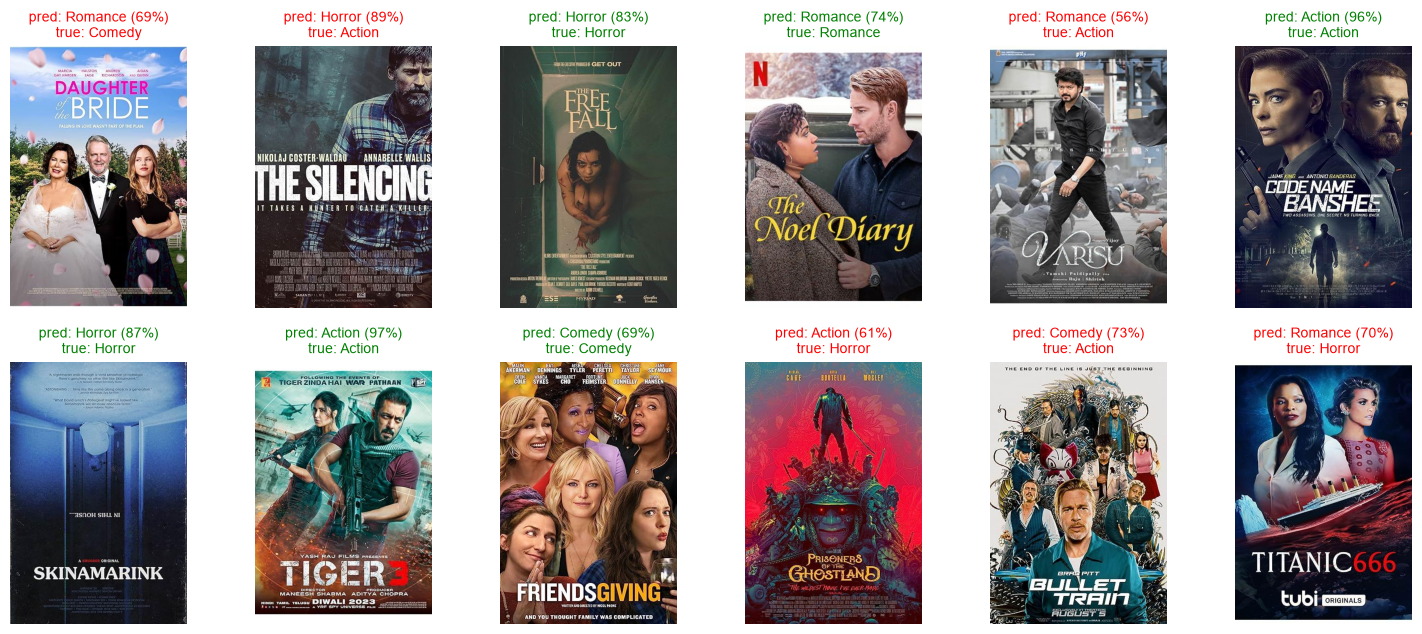

In [16]:
rng = random.Random(7)
idx = rng.sample(range(len(test_ds)), 12)
fig, axes = plt.subplots(2, 6, figsize=(15, 6.5))
for ax, i in zip(axes.flat, idx):
    path, label = test_ds.samples[i]
    ax.imshow(Image.open(path).convert("RGB"))
    ax.axis("off")
    pred, conf = probs[i].argmax(), probs[i].max()
    ax.set_title(f"pred: {class_names[pred]} ({conf:.0%})\ntrue: {class_names[label]}",
                 color="green" if pred == label else "red", fontsize=10)
plt.tight_layout()
plt.show()

## 8. Inference on a new poster

`predict_poster()` takes the path to any image file and returns the genre probabilities. The trained checkpoints are saved in `checkpoints/`.

In [17]:
@torch.no_grad()
def predict_poster(path, model=final_model):
    model.eval()
    x = eval_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    p = model(x).softmax(1).squeeze().cpu().numpy()
    return pd.Series(p, index=class_names).sort_values(ascending=False)

example = test_ds.samples[0][0]
print("Poster:", Path(example).name, "| true genre:", class_names[test_ds.samples[0][1]])
predict_poster(example).map("{:.1%}".format)

Poster: tt10127684.jpg | true genre: Action


Action     57.1%
Horror     42.1%
Comedy      0.6%
Romance     0.2%
dtype: str

## 9. Takeaways

The numbers below come from the run above.

In [18]:
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
per_class = pd.DataFrame(report).T.loc[class_names, ["precision", "recall", "f1-score"]]
easiest, hardest = per_class["f1-score"].idxmax(), per_class["f1-score"].idxmin()
off = cm.copy(); np.fill_diagonal(off, 0)
a, b = np.unravel_index(off.argmax(), off.shape)
print(f"Final model          : {final_name}")
print(f"Test accuracy        : {100 * (y_true == y_pred).mean():.1f}%  (random baseline 25%)")
print(f"Test macro-F1        : {f1_score(y_true, y_pred, average='macro'):.3f}")
print(f"Easiest genre        : {easiest} (F1 {per_class.loc[easiest, 'f1-score']:.2f})")
print(f"Hardest genre        : {hardest} (F1 {per_class.loc[hardest, 'f1-score']:.2f})")
print(f"Most common confusion: {class_names[a]} -> {class_names[b]} ({off[a, b]} posters)")

Final model          : ResNet50 (fine-tuned)
Test accuracy        : 63.8%  (random baseline 25%)
Test macro-F1        : 0.629
Easiest genre        : Horror (F1 0.72)
Hardest genre        : Comedy (F1 0.55)
Most common confusion: Comedy -> Romance (14 posters)
